## Dataset Preparation

In [ ]:
!pip install transformers
!pip install -q transformers datasets
!pip install transformers[torch]

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
import torch
import torch.nn as nn
import numpy as np
import ast
from datasets import Dataset, DatasetDict
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score
from transformers import RobertaTokenizerFast, RobertaForSequenceClassification, Trainer, TrainingArguments
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import BertTokenizerFast, BertForSequenceClassification
from transformers import EvalPrediction
import os
from datasets import load_dataset

In [ ]:
if torch.cuda.is_available():
    device = torch.cuda.get_device_name(0)
    print('GPU device:', device)
else:
    print('No GPU available.')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

GPU device: Tesla V100-SXM2-16GB


In [ ]:
drive.mount('/content/gdrive')
df = pd.read_csv('/content/gdrive/My Drive/MSc Project/fabsa.csv')


Mounted at /content/gdrive


Convert the representation of 'labels' and split the data

In [ ]:
# Convert the string representation of lists in 'labels' column to actual list
df['labels'] = df['labels'].apply(ast.literal_eval)

# Now you can generate the unique list of labels as before
labels = list(set([label for sublist in df['labels'].tolist() for label in sublist]))
id2label = {idx: label for idx, label in enumerate(labels)}
label2id = {label: idx for idx, label in enumerate(labels)}

Load dataset

In [ ]:
# Load data set and convert the string representation of lists in 'labels' column to actual list for each train and val data set
train_subset01 = pd.read_csv("/content/gdrive/My Drive/MSc Project/train_subset.csv", converters={'labels': ast.literal_eval})
val_df = pd.read_csv("/content/gdrive/My Drive/MSc Project/val_df.csv", converters={'labels': ast.literal_eval})

# Convert the pandas DataFrame to a Hugging Face Dataset
train_dataset = Dataset.from_pandas(train_subset01)
val_dataset = Dataset.from_pandas(val_df)

all_datasets = {}

dataset_key = "original_subset01"

# Combine them into a DatasetDict
dataset = DatasetDict({
        'train': train_dataset,
        'validation': val_dataset
    })

all_datasets[dataset_key] = dataset

In [ ]:
# Load data set and convert the string representation of lists in 'labels' column to actual list for each train and val data set
train_subset05 = pd.read_csv("/content/gdrive/My Drive/MSc Project/train_subset5.csv", converters={'labels': ast.literal_eval})
val_df = pd.read_csv("/content/gdrive/My Drive/MSc Project/val_df.csv", converters={'labels': ast.literal_eval})

# Convert the pandas DataFrame to a Hugging Face Dataset
train_dataset = Dataset.from_pandas(train_subset05)
val_dataset = Dataset.from_pandas(val_df)

dataset_key = "original_subset05"

# Combine them into a DatasetDict
dataset = DatasetDict({
        'train': train_dataset,
        'validation': val_dataset
    })

all_datasets[dataset_key] = dataset

In [ ]:
# Load data set and convert the string representation of lists in 'labels' column to actual list for each train and val data set
train_subset10 = pd.read_csv("/content/gdrive/My Drive/MSc Project/train_subset10.csv", converters={'labels': ast.literal_eval})
val_df = pd.read_csv("/content/gdrive/My Drive/MSc Project/val_df.csv", converters={'labels': ast.literal_eval})

# Convert the pandas DataFrame to a Hugging Face Dataset
train_dataset = Dataset.from_pandas(train_subset10)
val_dataset = Dataset.from_pandas(val_df)

dataset_key = "original_subset10"

# Combine them into a DatasetDict
dataset = DatasetDict({
        'train': train_dataset,
        'validation': val_dataset
    })

all_datasets[dataset_key] = dataset

In [ ]:
# Load data set and convert the string representation of lists in 'labels' column to actual list for each train and val data set
train_subset20 = pd.read_csv("/content/gdrive/My Drive/MSc Project/train_subset20.csv", converters={'labels': ast.literal_eval})
val_df = pd.read_csv("/content/gdrive/My Drive/MSc Project/val_df.csv", converters={'labels': ast.literal_eval})

# Convert the pandas DataFrame to a Hugging Face Dataset
train_dataset = Dataset.from_pandas(train_subset20)
val_dataset = Dataset.from_pandas(val_df)

dataset_key = "original_subset20"

# Combine them into a DatasetDict
dataset = DatasetDict({
        'train': train_dataset,
        'validation': val_dataset
    })

all_datasets[dataset_key] = dataset

In [ ]:
# Load data set and convert the string representation of lists in 'labels' column to actual list for each train and val data set
train_subset30 = pd.read_csv("/content/gdrive/My Drive/MSc Project/train_subset30.csv", converters={'labels': ast.literal_eval})
val_df = pd.read_csv("/content/gdrive/My Drive/MSc Project/val_df.csv", converters={'labels': ast.literal_eval})

# Convert the pandas DataFrame to a Hugging Face Dataset
train_dataset = Dataset.from_pandas(train_subset30)
val_dataset = Dataset.from_pandas(val_df)

dataset_key = "original_subset30"

# Combine them into a DatasetDict
dataset = DatasetDict({
        'train': train_dataset,
        'validation': val_dataset
    })

all_datasets[dataset_key] = dataset

Size of each subset

In [ ]:
print(len(train_subset01), len(train_subset05), len(train_subset10), len(train_subset20), len(train_subset30))

88 380 750 1517 2247


## Bert-base-uncased



In [ ]:
# Initialize tokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# Preprocessing function
def preprocess_data(examples):
    text = examples["text"]
    encoding = tokenizer(text, padding="max_length", truncation=True, max_length=128)

    labels_batch = examples["labels"]
    labels_matrix = np.zeros((len(text), len(labels)))

    for i, label_list in enumerate(labels_batch):
        for label in label_list:
            idx = label2id[label]
            labels_matrix[i, idx] = 1

    encoding["labels"] = labels_matrix.tolist()

    return encoding

# Define metrics
def multi_label_metrics(predictions, labels, threshold=0.5):
    sigmoid = torch.nn.Sigmoid()
    probs = sigmoid(torch.Tensor(predictions))
    y_pred = np.zeros(probs.shape)
    y_pred[np.where(probs >= threshold)] = 1
    y_true = labels
    f1_micro_average = f1_score(y_true=y_true, y_pred=y_pred, average='micro')
    roc_auc = roc_auc_score(y_true, y_pred, average = 'micro')
    accuracy = accuracy_score(y_true, y_pred)
    metrics = {'f1': f1_micro_average,
               'roc_auc': roc_auc,
               'accuracy': accuracy}
    return metrics

def compute_metrics(p: EvalPrediction):
    preds = p.predictions[0] if isinstance(p.predictions, tuple) else p.predictions
    result = multi_label_metrics(predictions=preds, labels=p.label_ids)
    return result

# Function to train and evaluate the model for a given dataset
def train_and_evaluate_model(dataset, dataset_key, lr, batch_size):
    print(f"Training with {dataset_key} data and lr {lr}, batch_size {batch_size}...")

    # Apply preprocessing
    encoded_dataset = dataset.map(preprocess_data, batched=True, remove_columns=['text', 'labels'])

    # Set format to PyTorch tensors
    encoded_dataset.set_format("torch")


    # Define the model
    model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased",
                                                               problem_type="multi_label_classification",
                                                               num_labels=len(labels),
                                                               id2label=id2label,
                                                               label2id=label2id)


    # Training arguments
    training_args = TrainingArguments(
        output_dir=f"bert-finetuned-{dataset_key}-lr-{lr}-batch-{batch_size}",
        evaluation_strategy="epoch",
        save_strategy="epoch",
        learning_rate=lr,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,  # Keeping eval batch size same as training for simplicity; you can change if needed.
        num_train_epochs=10,  # Fixed number of epochs
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
    )
    # Define the trainer
    trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=encoded_dataset["train"],
    eval_dataset=encoded_dataset["validation"],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
    )

    # Start training
    trainer.train()
    # Evaluate the model
    result = trainer.evaluate()
    print(f"Results with {dataset_key}: {result}")
    return result

## 1%

In [ ]:
# Load CSV file
hyperparam_bert_subset01 = pd.read_csv('/content/gdrive/My Drive/MSc Project/hyperparam_bert_subset01.csv')

In [ ]:
# Define the hyperparameters for tuning
HYPERPARAMETERS_TO_TUNE = {
    'learning_rate': [5e-5],
    'train_batch_size': [6],
}


# Select only the "original" dataset
dataset_key = "original_subset"
dataset = all_datasets[dataset_key]

# Iterate over all combinations of hyperparameters
for lr in HYPERPARAMETERS_TO_TUNE['learning_rate']:
    for batch_size in HYPERPARAMETERS_TO_TUNE['train_batch_size']:
        # Call the function for each combination of hyperparameters
        result = train_and_evaluate_model(dataset, dataset_key, lr, batch_size)

        # Append results to the DataFrame
        hyperparam_bert_subset01 = hyperparam_bert_subset01.append({
            'learning_rate': lr,
            'train_batch_size': batch_size,
            'f1_score': result['eval_f1'],
        }, ignore_index=True)

Training with original_subset data and lr 5e-05, batch_size 6...


Map:   0%|          | 0/88 [00:00<?, ? examples/s]

Map:   0%|          | 0/3173 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:411: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,No log,0.482978,0.135137,0.546571,0.000315
2,No log,0.318061,0.000000,0.500000,0.000000
3,No log,0.250485,0.000000,0.500000,0.000000
4,No log,0.218278,0.000000,0.500000,0.000000
5,No log,0.202692,0.000000,0.500000,0.000000
6,No log,0.193056,0.000000,0.500000,0.000000
7,No log,0.187552,0.000000,0.500000,0.000000
8,No log,0.184331,0.000000,0.500000,0.000000
9,No log,0.182505,0.000000,0.500000,0.000000
10,No log,0.181865,0.000000,0.500000,0.000000


Results with original_subset: {'eval_loss': 0.48297786712646484, 'eval_f1': 0.1351373924663827, 'eval_roc_auc': 0.5465706982958894, 'eval_accuracy': 0.0003151591553734636, 'eval_runtime': 8.5239, 'eval_samples_per_second': 372.249, 'eval_steps_per_second': 62.061, 'epoch': 10.0}


<ipython-input-24-4cf8700d7120>:19: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  hyperparam_results_subset = hyperparam_results_subset.append({


In [ ]:
# Save the DataFrame to the CSV file
hyperparam_bert_subset01.to_csv('/content/gdrive/My Drive/MSc Project/hyperparam_bert_subset01.csv', index=False)

In [ ]:
# Print out the best hyperparameters
best_hyperparams = hyperparam_bert_subset01.loc[hyperparam_bert_subset01['f1_score'].idxmax()]
print(f"Best hyperparameters for bert-base-uncased model:\n{best_hyperparams}")

Best hyperparameters for bert-base-uncased model:
learning_rate        0.000050
train_batch_size    16.000000
f1_score             0.152005
Name: 10, dtype: float64


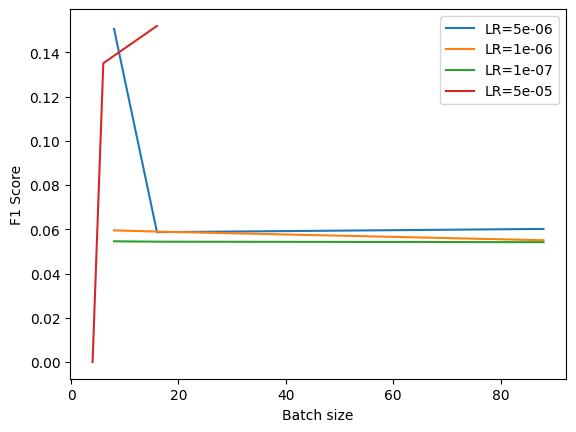

In [ ]:
# Extract unique learning rates from the DataFrame
learning_rates = hyperparam_bert_subset01['learning_rate'].unique()

# Plot the results
for lr in learning_rates:
    temp_df = hyperparam_bert_subset01[hyperparam_bert_subset01['learning_rate'] == lr]

    # Sort temp_df by 'train_batch_size' before plotting
    temp_df = temp_df.sort_values(by='train_batch_size')

    plt.plot(temp_df['train_batch_size'], temp_df['f1_score'], label=f'LR={lr}')

plt.xlabel('Batch size')
plt.ylabel('F1 Score')
plt.legend()
plt.show()

In [ ]:
hyperparam_bert_subset01

,learning_rate,train_batch_size,f1_score
0,5.000000e-06,8.0,0.150654
1,5.000000e-06,16.0,0.058697
2,5.000000e-06,88.0,0.060167
3,1.000000e-06,8.0,0.059517
4,1.000000e-06,16.0,0.058960
5,1.000000e-06,88.0,0.055046
6,1.000000e-07,8.0,0.054566
7,1.000000e-07,16.0,0.054394
8,1.000000e-07,88.0,0.054179
9,5.000000e-05,4.0,0.000000


## 5%

In [ ]:
# Load CSV file
hyperparam_bert_subset05 = pd.read_csv('/content/gdrive/My Drive/MSc Project/hyperparam_bert_subset05.csv')

In [ ]:
# Define the hyperparameters for tuning
HYPERPARAMETERS_TO_TUNE = {
    'learning_rate': [8e-5],
    'train_batch_size': [2, 4],
}


# Select only the "original" dataset
dataset_key = "original_subset05"
dataset = all_datasets[dataset_key]

# Iterate over all combinations of hyperparameters
for lr in HYPERPARAMETERS_TO_TUNE['learning_rate']:
    for batch_size in HYPERPARAMETERS_TO_TUNE['train_batch_size']:
        # Call the function for each combination of hyperparameters
        result = train_and_evaluate_model(dataset, dataset_key, lr, batch_size)

        # Append results to the DataFrame
        hyperparam_bert_subset05 = hyperparam_bert_subset05.append({
            'learning_rate': lr,
            'train_batch_size': batch_size,
            'f1_score': result['eval_f1'],
        }, ignore_index=True)

Training with original_subset05 data and lr 8e-05, batch_size 2...


Map:   0%|          | 0/380 [00:00<?, ? examples/s]

Map:   0%|          | 0/3173 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:411: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,No log,0.155485,0.000000,0.500000,0.000000
2,No log,0.144882,0.199167,0.558771,0.061771
3,0.176500,0.128133,0.317097,0.599373,0.140561
4,0.176500,0.122197,0.448925,0.661238,0.220927
5,0.176500,0.113831,0.483477,0.675084,0.249606
6,0.120800,0.107256,0.530564,0.698639,0.274819
7,0.120800,0.104885,0.558239,0.716972,0.290577
8,0.089500,0.102305,0.572966,0.724472,0.306965
9,0.089500,0.099142,0.582792,0.728674,0.307910
10,0.089500,0.098406,0.590157,0.734895,0.311377


...

Map:   0%|          | 0/3173 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:411: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,No log,0.160972,0.000000,0.500000,0.000000
2,No log,0.154244,0.049244,0.512297,0.005673
3,No log,0.144876,0.000000,0.500000,0.000000
4,No log,0.133360,0.160180,0.543892,0.039080
5,No log,0.126044,0.431496,0.649490,0.190671
6,0.168400,0.120072,0.466194,0.664418,0.228175
7,0.168400,0.115985,0.496794,0.683253,0.247715
8,0.168400,0.113424,0.464330,0.663974,0.222818
9,0.168400,0.110846,0.491449,0.677878,0.242673
10,0.168400,0.110388,0.494496,0.679465,0.245509


Results with original_subset05: {'eval_loss': 0.11598515510559082, 'eval_f1': 0.49679411066255047, 'eval_roc_auc': 0.6832531427183751, 'eval_accuracy': 0.2477150961235424, 'eval_runtime': 10.8676, 'eval_samples_per_second': 291.968, 'eval_steps_per_second': 73.061, 'epoch': 10.0}


<ipython-input-28-92dbdad7d230>:19: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  hyperparam_results_subset05 = hyperparam_results_subset05.append({


In [ ]:
hyperparam_bert_subset05

,learning_rate,train_batch_size,f1_score
0,0.000005,4.0,0.058186
1,0.000050,4.0,0.512479
2,0.000050,2.0,0.572113
3,0.000060,2.0,0.596205
4,0.000070,2.0,0.599492
5,0.000080,2.0,0.590157
6,0.000080,4.0,0.496794


In [ ]:
# Print out the best hyperparameters
best_hyperparams = hyperparam_bert_subset05.loc[hyperparam_bert_subset05['f1_score'].idxmax()]
print(f"Best hyperparameters for bert-base-uncased model:\n{best_hyperparams}")

Best hyperparameters for bert-base-uncased model:
learning_rate       0.000070
train_batch_size    2.000000
f1_score            0.599492
Name: 4, dtype: float64


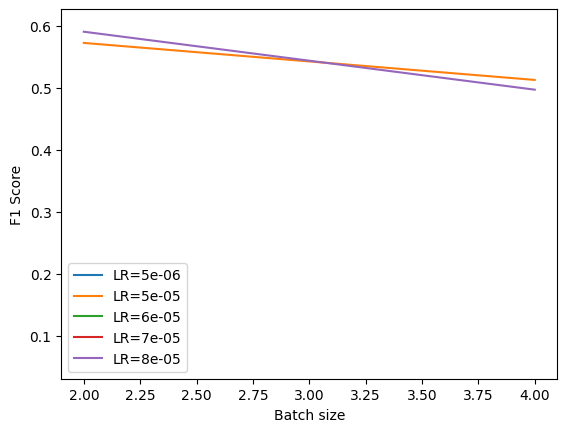

In [ ]:
# Extract unique learning rates from the DataFrame
learning_rates = hyperparam_bert_subset05['learning_rate'].unique()

# Plot the results
for lr in learning_rates:
    temp_df = hyperparam_bert_subset05[hyperparam_bert_subset05['learning_rate'] == lr]

    # Sort temp_df by 'train_batch_size' before plotting
    temp_df = temp_df.sort_values(by='train_batch_size')

    plt.plot(temp_df['train_batch_size'], temp_df['f1_score'], label=f'LR={lr}')

plt.xlabel('Batch size')
plt.ylabel('F1 Score')
plt.legend()
plt.show()

In [ ]:
# Save the DataFrame to the CSV file
hyperparam_bert_subset05.to_csv('/content/gdrive/My Drive/MSc Project/hyperparam_bert_subset05.csv', index=False)

## 10%

In [ ]:
# Load CSV file
hyperparam_bert_subset10 = pd.read_csv('/content/gdrive/My Drive/MSc Project/hyperparam_bert_subset10.csv')

In [ ]:
# Create a DataFrame to store the results
hyperparam_bert_subset10 = pd.DataFrame(columns=['learning_rate', 'train_batch_size', 'f1_score'])


In [ ]:
# Define the hyperparameters for tuning
HYPERPARAMETERS_TO_TUNE = {
    'learning_rate': [8e-5],
    'train_batch_size': [2],
}


dataset_key = "original_subset10"
dataset = all_datasets[dataset_key]

# Iterate over all combinations of hyperparameters
for lr in HYPERPARAMETERS_TO_TUNE['learning_rate']:
    for batch_size in HYPERPARAMETERS_TO_TUNE['train_batch_size']:
        # Call the function for each combination of hyperparameters
        result = train_and_evaluate_model(dataset, dataset_key, lr, batch_size)

        # Append results to the DataFrame
        hyperparam_bert_subset10 = hyperparam_bert_subset10.append({
            'learning_rate': lr,
            'train_batch_size': batch_size,
            'f1_score': result['eval_f1'],
        }, ignore_index=True)

        # Remove the folder after processing
        folder_path = f"/content/bert-finetuned-{dataset_key}-lr-{lr}-batch-{batch_size}"
        !rm -r $folder_path

Training with original_subset10 data and lr 6e-05, batch_size 2...


Map:   0%|          | 0/750 [00:00<?, ? examples/s]

Map:   0%|          | 0/3173 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:411: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,No log,0.147848,0.099848,0.526276,0.030255
2,0.182100,0.119955,0.459429,0.660481,0.233533
3,0.121700,0.110004,0.504836,0.683568,0.261582
4,0.102500,0.105944,0.506320,0.687839,0.259691
5,0.102500,0.097571,0.600608,0.742918,0.327766
6,0.081800,0.093449,0.618880,0.754745,0.343208
7,0.067800,0.090441,0.637451,0.764731,0.370942
8,0.057300,0.089139,0.650888,0.775505,0.387331
9,0.057300,0.088354,0.655325,0.779234,0.390482
10,0.049600,0.088347,0.657128,0.780474,0.393003


...

Map:   0%|          | 0/3173 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:411: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,No log,0.154404,0.000000,0.500000,0.000000
2,0.180900,0.153915,0.000000,0.500000,0.000000
3,0.155900,0.153396,0.000000,0.500000,0.000000
4,0.157800,0.153380,0.000000,0.500000,0.000000
5,0.157800,0.153107,0.000000,0.500000,0.000000
6,0.156600,0.153135,0.000000,0.500000,0.000000
7,0.156100,0.152801,0.000000,0.500000,0.000000
8,0.156000,0.152562,0.000000,0.500000,0.000000
9,0.156000,0.152583,0.000000,0.500000,0.000000
10,0.155400,0.152577,0.000000,0.500000,0.000000


Results with original_subset10: {'eval_loss': 0.15440422296524048, 'eval_f1': 0.0, 'eval_roc_auc': 0.5, 'eval_accuracy': 0.0, 'eval_runtime': 23.0579, 'eval_samples_per_second': 137.61, 'eval_steps_per_second': 68.827, 'epoch': 10.0}


<ipython-input-31-2242ca1d4364>:18: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  hyperparam_results_subset10 = hyperparam_results_subset10.append({


In [ ]:
hyperparam_bert_subset10

,learning_rate,train_batch_size,f1_score
0,0.000005,8.0,0.262631
1,0.000005,16.0,0.106623
2,0.000050,8.0,0.566777
3,0.000010,8.0,0.000000
4,0.000050,16.0,0.466815
5,0.000050,64.0,0.066114
6,0.000050,4.0,0.640120
7,0.000050,2.0,0.669542
8,0.000030,2.0,0.646315
9,0.000030,4.0,0.591225


In [ ]:
# Save the DataFrame to the CSV file
hyperparam_bert_subset10.to_csv('/content/gdrive/My Drive/MSc Project/hyperparam_bert_subset10.csv', index=False)

In [ ]:
# Print out the best hyperparameters
best_hyperparams = hyperparam_bert_subset10.loc[hyperparam_bert_subset10['f1_score'].idxmax()]
print(f"Best hyperparameters for bert-base-uncased model:\n{best_hyperparams}")

Best hyperparameters for bert-base-uncased model:
learning_rate       0.000050
train_batch_size    2.000000
f1_score            0.669542
Name: 7, dtype: float64


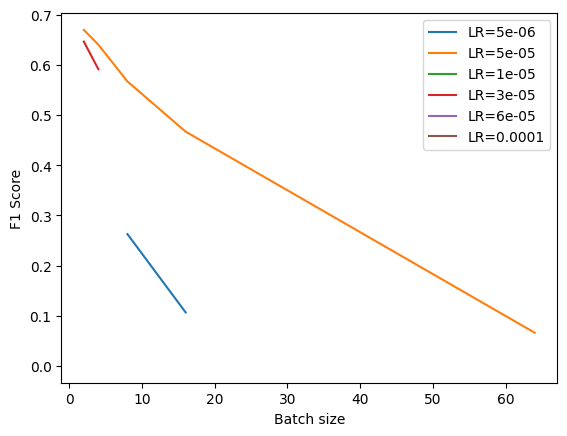

In [ ]:
# Extract unique learning rates from the DataFrame
learning_rates = hyperparam_bert_subset10['learning_rate'].unique()

# Plot the results
for lr in learning_rates:
    temp_df = hyperparam_bert_subset10[hyperparam_bert_subset10['learning_rate'] == lr]

    # Sort temp_df by 'train_batch_size' before plotting
    temp_df = temp_df.sort_values(by='train_batch_size')

    plt.plot(temp_df['train_batch_size'], temp_df['f1_score'], label=f'LR={lr}')

plt.xlabel('Batch size')
plt.ylabel('F1 Score')
plt.legend()
plt.show()

##20%

In [ ]:
# Create a DataFrame to store the results
hyperparam_bertbase_subset20 = pd.DataFrame(columns=['learning_rate', 'train_batch_size', 'f1_score'])

In [ ]:
# Create a DataFrame to store the results
hyperparam_bertbase_subset20 = pd.read_csv('/content/gdrive/My Drive/MSc Project/hyperparam_bertbase_subset20.csv')

In [ ]:
# Define the hyperparameters for tuning
HYPERPARAMETERS_TO_TUNE = {
    'learning_rate': [7e-5],
    'train_batch_size': [2],
}


dataset_key = "original_subset20"
dataset = all_datasets[dataset_key]

# Iterate over all combinations of hyperparameters
for lr in HYPERPARAMETERS_TO_TUNE['learning_rate']:
    for batch_size in HYPERPARAMETERS_TO_TUNE['train_batch_size']:
        # Call the function for each combination of hyperparameters
        result = train_and_evaluate_model(dataset, dataset_key, lr, batch_size)

        # Append results to the DataFrame
        hyperparam_bertbase_subset20 = hyperparam_bertbase_subset20.append({
            'learning_rate': lr,
            'train_batch_size': batch_size,
            'f1_score': result['eval_f1'],
        }, ignore_index=True)

        # Remove the folder after processing
        folder_path = f"/content/bert-finetuned-{dataset_key}-lr-{lr}-batch-{batch_size}"
        !rm -r $folder_path

        # Save the DataFrame to the CSV file
        hyperparam_bertbase_subset20.to_csv('/content/gdrive/My Drive/MSc Project/hyperparam_bertbase_subset20.csv', index=False)

        # Remove the folder after processing
        folder_path = f"/content/bert-finetuned-{dataset_key}-lr-{lr}-batch-{batch_size}"
        !rm -r $folder_path

Training with original_subset20 data and lr 7e-05, batch_size 2...


Map:   0%|          | 0/1517 [00:00<?, ? examples/s]

Map:   0%|          | 0/3173 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,0.178000,0.148349,0.000000,0.500000,0.000000
2,0.152600,0.153296,0.000000,0.500000,0.000000
3,0.152100,0.153266,0.000000,0.500000,0.000000
4,0.151500,0.154012,0.000000,0.500000,0.000000
5,0.150600,0.153615,0.000000,0.500000,0.000000
6,0.154000,0.153293,0.000000,0.500000,0.000000
7,0.155200,0.153094,0.000000,0.500000,0.000000
8,0.148700,0.152547,0.000000,0.500000,0.000000
9,0.150800,0.152508,0.000000,0.500000,0.000000
10,0.151600,0.152436,0.000000,0.500000,0.000000


Results with original_subset20: {'eval_loss': 0.1483488231897354, 'eval_f1': 0.0, 'eval_roc_auc': 0.5, 'eval_accuracy': 0.0, 'eval_runtime': 23.7386, 'eval_samples_per_second': 133.664, 'eval_steps_per_second': 66.853, 'epoch': 10.0}


<ipython-input-95-4be306648dd7>:18: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  hyperparam_bertbase_subset20 = hyperparam_bertbase_subset20.append({


rm: cannot remove '/content/bert-finetuned-original_subset20-lr-7e-05-batch-2': No such file or directory


In [ ]:
hyperparam_bertbase_subset20

,learning_rate,train_batch_size,f1_score
0,0.00005,2.0,0.707611
1,0.00005,16.0,0.625702
2,0.00003,2.0,0.705953
3,0.00003,16.0,0.539424
4,0.00007,2.0,0.000000


In [ ]:
# Print out the best hyperparameters
best_hyperparams = hyperparam_bertbase_subset20.loc[hyperparam_bertbase_subset20['f1_score'].idxmax()]
print(f"Best hyperparameters for bert-base-uncased model:\n{best_hyperparams}")

Best hyperparameters for bert-base-uncased model:
learning_rate       0.000050
train_batch_size    2.000000
f1_score            0.707611
Name: 0, dtype: float64


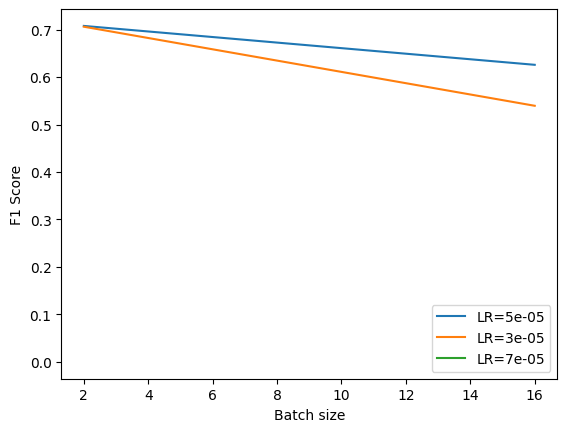

In [ ]:
# Extract unique learning rates from the DataFrame
learning_rates = hyperparam_bertbase_subset20['learning_rate'].unique()

# Plot the results
for lr in learning_rates:
    temp_df = hyperparam_bertbase_subset20[hyperparam_bertbase_subset20['learning_rate'] == lr]

    # Sort temp_df by 'train_batch_size' before plotting
    temp_df = temp_df.sort_values(by='train_batch_size')

    plt.plot(temp_df['train_batch_size'], temp_df['f1_score'], label=f'LR={lr}')

plt.xlabel('Batch size')
plt.ylabel('F1 Score')
plt.legend()
plt.show()

## 30%

In [ ]:
# Load CSV file
hyperparam_bert_subset30 = pd.read_csv('/content/gdrive/My Drive/MSc Project/hyperparam_bert_subset30.csv')

In [ ]:
# Create a DataFrame to store the results
hyperparam_bert_subset30 = pd.DataFrame(columns=['learning_rate', 'train_batch_size', 'f1_score'])

In [ ]:
# Define the hyperparameters for tuning
HYPERPARAMETERS_TO_TUNE = {
    'learning_rate': [5e-5],
    'train_batch_size': [4,8],
}


dataset_key = "original_subset30"
dataset = all_datasets[dataset_key]

# Iterate over all combinations of hyperparameters
for lr in HYPERPARAMETERS_TO_TUNE['learning_rate']:
    for batch_size in HYPERPARAMETERS_TO_TUNE['train_batch_size']:
        # Call the function for each combination of hyperparameters
        result = train_and_evaluate_model(dataset, dataset_key, lr, batch_size)

        # Append results to the DataFrame
        hyperparam_bert_subset30 = hyperparam_bert_subset30.append({
            'learning_rate': lr,
            'train_batch_size': batch_size,
            'f1_score': result['eval_f1'],
        }, ignore_index=True)

        # Remove the folder after processing
        folder_path = f"/content/bert-finetuned-{dataset_key}-lr-{lr}-batch-{batch_size}"
        !rm -r $folder_path

Training with original_subset30 data and lr 5e-05, batch_size 4...


Map:   0%|          | 0/2247 [00:00<?, ? examples/s]

Map:   0%|          | 0/3173 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:411: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(
You're using a BertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,0.170900,0.125591,0.409247,0.644445,0.150646
2,0.112200,0.095021,0.615948,0.751149,0.335645
3,0.084500,0.084031,0.665627,0.781685,0.400252
4,0.069200,0.079997,0.682882,0.794127,0.427986
5,0.056700,0.075119,0.719417,0.825897,0.460763
6,0.046600,0.073500,0.726370,0.828460,0.470217
7,0.037300,0.072079,0.736399,0.838859,0.479672
8,0.031100,0.070913,0.741482,0.839270,0.495115
9,0.022700,0.071274,0.741296,0.839421,0.496691
10,0.021200,0.071818,0.743145,0.843529,0.496061


...

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:411: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,No log,0.137783,0.297064,0.590617,0.091081
2,0.167700,0.110255,0.504440,0.684596,0.231642


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,No log,0.137783,0.297064,0.590617,0.091081
2,0.167700,0.110255,0.504440,0.684596,0.231642
3,0.167700,0.097591,0.577354,0.728443,0.306335
4,0.093200,0.088326,0.664722,0.780905,0.396155
5,0.093200,0.082257,0.680208,0.787850,0.421053
6,0.066100,0.079225,0.687042,0.793274,0.439017
7,0.066100,0.077278,0.702413,0.806433,0.449102
8,0.048700,0.075710,0.707006,0.809880,0.456035
9,0.038800,0.075238,0.712438,0.815324,0.460448
10,0.038800,0.075117,0.714752,0.818063,0.464229


Results with original_subset30: {'eval_loss': 0.07511694729328156, 'eval_f1': 0.7147521519738795, 'eval_roc_auc': 0.8180626612499873, 'eval_accuracy': 0.4642294358651119, 'eval_runtime': 7.0175, 'eval_samples_per_second': 452.154, 'eval_steps_per_second': 56.573, 'epoch': 10.0}


<ipython-input-10-db29136e9e24>:18: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  hyperparam_results_subset30 = hyperparam_results_subset30.append({


In [ ]:
hyperparam_bert_subset30

,learning_rate,train_batch_size,f1_score
0,0.00005,4.0,0.743145
1,0.00005,8.0,0.714752


In [ ]:
# Save the DataFrame to the CSV file
hyperparam_bert_subset30.to_csv('/content/gdrive/My Drive/MSc Project/hyperparam_bert_subset30.csv', index=False)

In [ ]:
# Print out the best hyperparameters
best_hyperparams = hyperparam_bert_subset30.loc[hyperparam_bert_subset30['f1_score'].idxmax()]
print(f"Best hyperparameters for bert-base-uncased model:\n{best_hyperparams}")

Best hyperparameters for bert-base-uncased model:
learning_rate       0.000050
train_batch_size    4.000000
f1_score            0.743145
Name: 0, dtype: float64


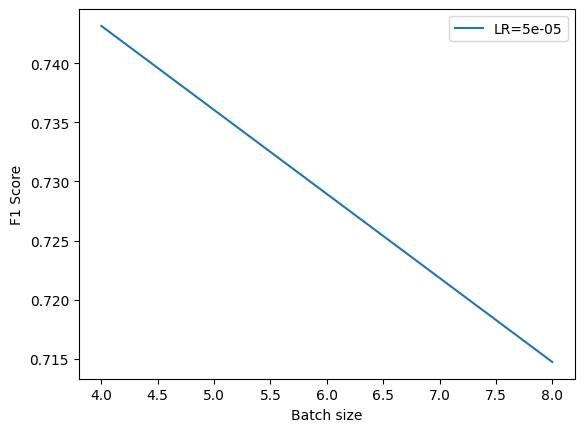

In [ ]:
# Extract unique learning rates from the DataFrame
learning_rates = hyperparam_bert_subset30['learning_rate'].unique()

# Plot the results
for lr in learning_rates:
    temp_df = hyperparam_bert_subset30[hyperparam_bert_subset30['learning_rate'] == lr]

    # Sort temp_df by 'train_batch_size' before plotting
    temp_df = temp_df.sort_values(by='train_batch_size')

    plt.plot(temp_df['train_batch_size'], temp_df['f1_score'], label=f'LR={lr}')

plt.xlabel('Batch size')
plt.ylabel('F1 Score')
plt.legend()
plt.show()

## Bert-large-uncased

In [ ]:
# Initialize tokenizer and define model
tokenizer = BertTokenizerFast.from_pretrained("bert-large-uncased")

# Preprocessing function
def preprocess_data(examples):
    text = examples["text"]
    encoding = tokenizer(text, padding="max_length", truncation=True, max_length=128)

    labels_batch = examples["labels"]
    labels_matrix = np.zeros((len(text), len(labels)))

    for i, label_list in enumerate(labels_batch):
        for label in label_list:
            idx = label2id[label]
            labels_matrix[i, idx] = 1

    encoding["labels"] = labels_matrix.tolist()

    return encoding

# Define metrics
def multi_label_metrics(predictions, labels, threshold=0.5):
    sigmoid = torch.nn.Sigmoid()
    probs = sigmoid(torch.Tensor(predictions))
    y_pred = np.zeros(probs.shape)
    y_pred[np.where(probs >= threshold)] = 1
    y_true = labels
    f1_micro_average = f1_score(y_true=y_true, y_pred=y_pred, average='micro')
    roc_auc = roc_auc_score(y_true, y_pred, average='micro')
    accuracy = accuracy_score(y_true, y_pred)
    metrics = {'f1': f1_micro_average,
               'roc_auc': roc_auc,
               'accuracy': accuracy}
    return metrics

def compute_metrics(p: EvalPrediction):
    preds = p.predictions[0] if isinstance(p.predictions, tuple) else p.predictions
    result = multi_label_metrics(predictions=preds, labels=p.label_ids)
    return result

# Function to train and evaluate the model for a given augmented dataset
def train_and_evaluate_model(dataset, dataset_key, lr, batch_size):
    print(f"Training with {dataset_key} data and lr {lr}, batch_size {batch_size}...")

    # Apply preprocessing
    encoded_dataset = dataset.map(preprocess_data, batched=True, remove_columns=['text', 'labels'])
    # Set format to PyTorch tensors
    encoded_dataset.set_format("torch")


    model = BertForSequenceClassification.from_pretrained("bert-large-uncased", num_labels=len(labels))

    # Training arguments
    training_args = TrainingArguments(
        output_dir=f"bert-finetuned-{dataset_key}-lr-{lr}-batch-{batch_size}",
        evaluation_strategy="epoch",
        save_strategy="epoch",
        learning_rate=lr,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=10,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
    )
    # Define the trainer
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=encoded_dataset["train"],
        eval_dataset=encoded_dataset["validation"],
        tokenizer=tokenizer,
        compute_metrics=compute_metrics,
    )
    # Start training
    trainer.train()
    # Evaluate the model
    result = trainer.evaluate()
    print(f"Results with {dataset_key}: {result}")
    return result


##1%

In [ ]:
# Create a DataFrame to store the results
hyperparam_results_subset_bertlarge = pd.read_csv('/content/gdrive/My Drive/MSc Project/hyperparam_results_subset_bertlarge.csv')

In [ ]:
# Define the hyperparameters for tuning
HYPERPARAMETERS_TO_TUNE = {
    'learning_rate': [5e-5],
    'train_batch_size':[8, 16],
}

# Select only the "original" dataset
dataset_key = "original_subset01"
dataset = all_datasets[dataset_key]

# Iterate over all combinations of hyperparameters
for lr in HYPERPARAMETERS_TO_TUNE['learning_rate']:
    for batch_size in HYPERPARAMETERS_TO_TUNE['train_batch_size']:
        # Call the function for each combination of hyperparameters
        result = train_and_evaluate_model(dataset, dataset_key, lr, batch_size)

        # Append results to the DataFrame
        hyperparam_results_subset_bertlarge = hyperparam_results_subset_bertlarge.append({
            'learning_rate': lr,
            'train_batch_size': batch_size,
            'f1_score': result['eval_f1'],
        }, ignore_index=True)
        # Save the DataFrame to the CSV file
        hyperparam_results_subset_bertlarge.to_csv('/content/gdrive/My Drive/MSc Project/hyperparam_results_subset_bertlarge.csv', index=False)

        # Remove the folder after processing
        folder_path = f"/content/bert-finetuned-{dataset_key}-lr-{lr}-batch-{batch_size}"
        !rm -r $folder_path


Training with original_subset01 data and lr 5e-05, batch_size 8...


Map:   0%|          | 0/88 [00:00<?, ? examples/s]

Map:   0%|          | 0/3173 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-large-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,No log,0.429067,0.063955,0.512163,0.007879
2,No log,0.260149,0.000000,0.500000,0.000000
3,No log,0.207339,0.000000,0.500000,0.000000
4,No log,0.186898,0.000000,0.500000,0.000000
5,No log,0.177646,0.000000,0.500000,0.000000
6,No log,0.172314,0.000000,0.500000,0.000000
7,No log,0.168977,0.000000,0.500000,0.000000
8,No log,0.166551,0.000000,0.500000,0.000000
9,No log,0.165207,0.000000,0.500000,0.000000
10,No log,0.164661,0.000000,0.500000,0.000000


...

Map:   0%|          | 0/3173 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-large-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,No log,0.538709,0.121459,0.545097,0.000630
2,No log,0.379150,0.001867,0.496784,0.000315
3,No log,0.298550,0.000000,0.500000,0.000000
4,No log,0.251053,0.000000,0.500000,0.000000
5,No log,0.221606,0.000000,0.500000,0.000000
6,No log,0.207395,0.000000,0.500000,0.000000
7,No log,0.199329,0.000000,0.500000,0.000000
8,No log,0.194385,0.000000,0.500000,0.000000
9,No log,0.191633,0.000000,0.500000,0.000000
10,No log,0.190808,0.000000,0.500000,0.000000


Results with original_subset01: {'eval_loss': 0.5387086868286133, 'eval_f1': 0.12145932472241106, 'eval_roc_auc': 0.545097215739957, 'eval_accuracy': 0.0006303183107469272, 'eval_runtime': 23.5687, 'eval_samples_per_second': 134.627, 'eval_steps_per_second': 8.443, 'epoch': 10.0}


<ipython-input-31-4bb64c2979c6>:18: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  hyperparam_results_subset_bertlarge = hyperparam_results_subset_bertlarge.append({


In [ ]:
hyperparam_results_subset_bertlarge

,learning_rate,train_batch_size,f1_score
2,5.000000e-06,16.0,0.129228
3,5.000000e-06,88.0,0.109988
4,1.000000e-06,8.0,0.115108
5,1.000000e-06,16.0,0.109525
6,1.000000e-06,88.0,0.105493
7,1.000000e-07,8.0,0.105609
8,1.000000e-07,16.0,0.105666
9,1.000000e-07,88.0,0.105971
10,6.000000e-05,8.0,0.073755
11,6.000000e-05,16.0,0.118371


In [ ]:
# Print out the best hyperparameters
best_hyperparams = hyperparam_results_subset_bertlarge.loc[hyperparam_results_subset_bertlarge['f1_score'].idxmax()]
print(f"Best hyperparameters for bert-large-uncased model:\n{best_hyperparams}")

Best hyperparameters for bert-large-uncased model:
learning_rate        0.000050
train_batch_size    24.000000
f1_score             0.139212
Name: 17, dtype: float64


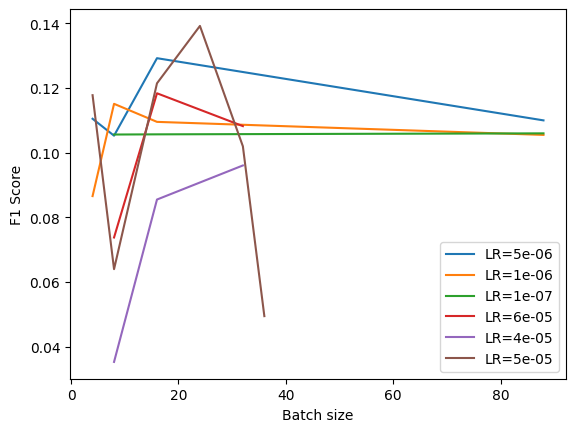

In [ ]:
# Extract unique learning rates from the DataFrame
learning_rates = hyperparam_results_subset_bertlarge['learning_rate'].unique()

# Plot the results
for lr in learning_rates:
    temp_df = hyperparam_results_subset_bertlarge[hyperparam_results_subset_bertlarge['learning_rate'] == lr]

    # Sort temp_df by 'train_batch_size' before plotting
    temp_df = temp_df.sort_values(by='train_batch_size')

    plt.plot(temp_df['train_batch_size'], temp_df['f1_score'], label=f'LR={lr}')

plt.xlabel('Batch size')
plt.ylabel('F1 Score')
plt.legend()
plt.show()

##5%

In [ ]:
# Create a DataFrame to store the results
hyperparam_results_subset05_bertlarge = pd.DataFrame(columns=['learning_rate', 'train_batch_size', 'f1_score'])

In [ ]:
# Create a DataFrame to store the results
hyperparam_results_subset05_bertlarge = pd.read_csv('/content/gdrive/My Drive/MSc Project/hyperparam_results_subset05_bertlarge.csv')

In [ ]:
# Define the hyperparameters for tuning
HYPERPARAMETERS_TO_TUNE = {
    'learning_rate': [5e-5],
    'train_batch_size':[2],
}

# Select only the "original" dataset
dataset_key = "original_subset05"
dataset = all_datasets[dataset_key]

# Iterate over all combinations of hyperparameters
for lr in HYPERPARAMETERS_TO_TUNE['learning_rate']:
    for batch_size in HYPERPARAMETERS_TO_TUNE['train_batch_size']:
        # Call the function for each combination of hyperparameters
        result = train_and_evaluate_model(dataset, dataset_key, lr, batch_size)

        # Append results to the DataFrame
        hyperparam_results_subset05_bertlarge = hyperparam_results_subset05_bertlarge.append({
            'learning_rate': lr,
            'train_batch_size': batch_size,
            'f1_score': result['eval_f1'],
        }, ignore_index=True)
        # Save the DataFrame to the CSV file
        hyperparam_results_subset05_bertlarge.to_csv('/content/gdrive/My Drive/MSc Project/hyperparam_results_subset05_bertlarge.csv', index=False)

        # Remove the folder after processing
        folder_path = f"/content/bert-finetuned-{dataset_key}-lr-{lr}-batch-{batch_size}"
        !rm -r $folder_path


Training with original_subset05 data and lr 5e-05, batch_size 2...


Map:   0%|          | 0/380 [00:00<?, ? examples/s]

Map:   0%|          | 0/3173 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-large-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,No log,0.152056,0.000357,0.500085,0.000000
2,No log,0.136296,0.178162,0.549687,0.036874
3,0.197700,0.154193,0.000000,0.500000,0.000000
4,0.197700,0.154064,0.000000,0.500000,0.000000
5,0.197700,0.154059,0.000000,0.500000,0.000000
6,0.163600,0.153161,0.000000,0.500000,0.000000
7,0.163600,0.152955,0.000000,0.500000,0.000000
8,0.162600,0.152993,0.000000,0.500000,0.000000
9,0.162600,0.152877,0.000000,0.500000,0.000000
10,0.162600,0.152933,0.000000,0.500000,0.000000


Results with original_subset05: {'eval_loss': 0.13629555702209473, 'eval_f1': 0.1781618224666143, 'eval_roc_auc': 0.5496870181196962, 'eval_accuracy': 0.03687362117869524, 'eval_runtime': 47.1787, 'eval_samples_per_second': 67.255, 'eval_steps_per_second': 33.638, 'epoch': 10.0}


<ipython-input-51-eef1ca8ca7d0>:18: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  hyperparam_results_subset05_bertlarge = hyperparam_results_subset05_bertlarge.append({


In [ ]:
hyperparam_results_subset05_bertlarge

,learning_rate,train_batch_size,f1_score
0,0.000005,8.0,0.101725
1,0.000005,16.0,0.097553
2,0.000005,32.0,0.109290
3,0.000050,8.0,0.464538
4,0.000050,16.0,0.462451
5,0.000050,32.0,0.000000
6,0.000500,8.0,0.000000
7,0.000500,16.0,0.000000
8,0.000500,32.0,0.000000
9,0.000060,4.0,0.000000


In [ ]:
# Print out the best hyperparameters
best_hyperparams = hyperparam_results_subset05_bertlarge.loc[hyperparam_results_subset05_bertlarge['f1_score'].idxmax()]
print(f"Best hyperparameters for bert-large-uncased model:\n{best_hyperparams}")

Best hyperparameters for bert-large-uncased model:
learning_rate       0.000050
train_batch_size    4.000000
f1_score            0.626569
Name: 10, dtype: float64


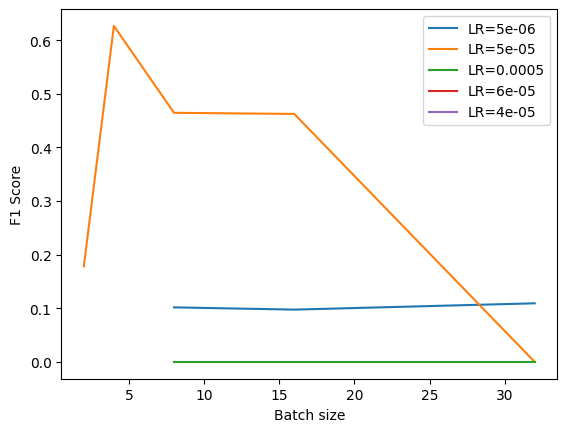

In [ ]:
# Extract unique learning rates from the DataFrame
learning_rates = hyperparam_results_subset05_bertlarge['learning_rate'].unique()

# Plot the results
for lr in learning_rates:
    temp_df = hyperparam_results_subset05_bertlarge[hyperparam_results_subset05_bertlarge['learning_rate'] == lr]

    # Sort temp_df by 'train_batch_size' before plotting
    temp_df = temp_df.sort_values(by='train_batch_size')

    plt.plot(temp_df['train_batch_size'], temp_df['f1_score'], label=f'LR={lr}')

plt.xlabel('Batch size')
plt.ylabel('F1 Score')
plt.legend()
plt.show()

##10%

In [ ]:
# Create a DataFrame to store the results
hyperparam_results_subset10_bertlarge = pd.DataFrame(columns=['learning_rate', 'train_batch_size', 'f1_score'])

In [ ]:
# Create a DataFrame to store the results
hyperparam_results_subset10_bertlarge = pd.read_csv('/content/gdrive/My Drive/MSc Project/hyperparam_results_subset10_bertlarge.csv')

In [ ]:
# Define the hyperparameters for tuning
HYPERPARAMETERS_TO_TUNE = {
    'learning_rate': [1e-5, 5e-5, 3e-5, 4e-5],
    'train_batch_size':[2],
}

# Select only the "original" dataset
dataset_key = "original_subset10"
dataset = all_datasets[dataset_key]

# Iterate over all combinations of hyperparameters
for lr in HYPERPARAMETERS_TO_TUNE['learning_rate']:
    for batch_size in HYPERPARAMETERS_TO_TUNE['train_batch_size']:
        # Call the function for each combination of hyperparameters
        result = train_and_evaluate_model(dataset, dataset_key, lr, batch_size)

        # Append results to the DataFrame
        hyperparam_results_subset10_bertlarge = hyperparam_results_subset10_bertlarge.append({
            'learning_rate': lr,
            'train_batch_size': batch_size,
            'f1_score': result['eval_f1'],
        }, ignore_index=True)
        # Save the DataFrame to the CSV file
        hyperparam_results_subset10_bertlarge.to_csv('/content/gdrive/My Drive/MSc Project/hyperparam_results_subset10_bertlarge.csv', index=False)

        # Remove the folder after processing
        folder_path = f"/content/bert-finetuned-{dataset_key}-lr-{lr}-batch-{batch_size}"
        !rm -r $folder_path


Training with original_subset10 data and lr 1e-05, batch_size 2...


Map:   0%|          | 0/750 [00:00<?, ? examples/s]

Map:   0%|          | 0/3173 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-large-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,No log,0.157544,0.000000,0.500000,0.000000
2,0.235500,0.129056,0.412275,0.636215,0.188780
3,0.131200,0.115628,0.504689,0.684388,0.251497
4,0.108200,0.107356,0.520394,0.688436,0.260321
5,0.108200,0.101522,0.581254,0.727396,0.315159
6,0.088100,0.098338,0.592593,0.731779,0.315789
7,0.076700,0.095339,0.608943,0.744364,0.335014
8,0.067800,0.093772,0.628165,0.756491,0.350457
9,0.067800,0.092614,0.630507,0.758709,0.357706
10,0.062600,0.092266,0.630158,0.756784,0.357706


...

Map:   0%|          | 0/3173 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-large-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,No log,0.139793,0.308178,0.603724,0.082887
2,0.178600,0.115158,0.521808,0.700265,0.273558
3,0.111200,0.253868,0.337045,0.684756,0.220296
4,0.090700,0.093409,0.603761,0.738898,0.353609
5,0.090700,0.086344,0.661738,0.783182,0.400252
6,0.068100,0.087814,0.652755,0.775074,0.389537
7,0.052100,0.082796,0.683297,0.800821,0.415065
8,0.042200,0.081569,0.691741,0.809271,0.422944
9,0.042200,0.080433,0.698938,0.815075,0.435235
10,0.033300,0.080007,0.698438,0.812300,0.434920


Results with original_subset10: {'eval_loss': 0.08043278753757477, 'eval_f1': 0.6989383461575923, 'eval_roc_auc': 0.8150751236586966, 'eval_accuracy': 0.43523479357075323, 'eval_runtime': 40.9358, 'eval_samples_per_second': 77.512, 'eval_steps_per_second': 38.768, 'epoch': 10.0}


<ipython-input-68-41a6aa2acb38>:18: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  hyperparam_results_subset10_bertlarge = hyperparam_results_subset10_bertlarge.append({


In [ ]:
hyperparam_results_subset10_bertlarge

,learning_rate,train_batch_size,f1_score
0,0.00005,4.0,0.000000
1,0.00005,8.0,0.546924
2,0.00005,16.0,0.621583
3,0.00003,4.0,0.673196
4,0.00003,8.0,0.632920
5,0.00003,16.0,0.539357
6,0.00001,4.0,0.546303
7,0.00001,8.0,0.480712
8,0.00001,16.0,0.158654
9,0.00004,4.0,0.680938


In [ ]:
# Print out the best hyperparameters
best_hyperparams = hyperparam_results_subset10_bertlarge.loc[hyperparam_results_subset10_bertlarge['f1_score'].idxmax()]
print(f"Best hyperparameters for bert-large-uncased model:\n{best_hyperparams}")

Best hyperparameters for bert-large-uncased model:
learning_rate       0.000030
train_batch_size    2.000000
f1_score            0.700226
Name: 14, dtype: float64


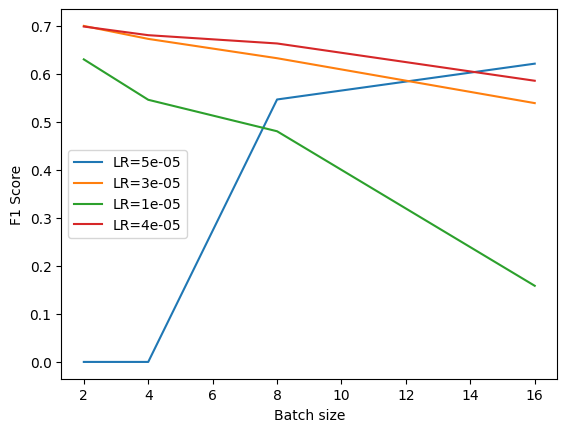

In [ ]:
# Extract unique learning rates from the DataFrame
learning_rates = hyperparam_results_subset10_bertlarge['learning_rate'].unique()

# Plot the results
for lr in learning_rates:
    temp_df = hyperparam_results_subset10_bertlarge[hyperparam_results_subset10_bertlarge['learning_rate'] == lr]

    # Sort temp_df by 'train_batch_size' before plotting
    temp_df = temp_df.sort_values(by='train_batch_size')

    plt.plot(temp_df['train_batch_size'], temp_df['f1_score'], label=f'LR={lr}')

plt.xlabel('Batch size')
plt.ylabel('F1 Score')
plt.legend()
plt.show()

##20%

In [ ]:
# Create a DataFrame to store the results
hyperparam_results_subset20_bertlarge = pd.DataFrame(columns=['learning_rate', 'train_batch_size', 'f1_score'])

In [ ]:
# Create a DataFrame to store the results
hyperparam_results_subset20_bertlarge = pd.read_csv('/content/gdrive/My Drive/MSc Project/hyperparam_results_subset20_bertlarge.csv')

In [ ]:
# Define the hyperparameters for tuning
HYPERPARAMETERS_TO_TUNE = {
    'learning_rate': [3e-5, 1e-5],
    'train_batch_size':[2],
}

# Select only the "original" dataset
dataset_key = "original_subset20"
dataset = all_datasets[dataset_key]

# Iterate over all combinations of hyperparameters
for lr in HYPERPARAMETERS_TO_TUNE['learning_rate']:
    for batch_size in HYPERPARAMETERS_TO_TUNE['train_batch_size']:
        # Call the function for each combination of hyperparameters
        result = train_and_evaluate_model(dataset, dataset_key, lr, batch_size)

        # Append results to the DataFrame
        hyperparam_results_subset20_bertlarge = hyperparam_results_subset20_bertlarge.append({
            'learning_rate': lr,
            'train_batch_size': batch_size,
            'f1_score': result['eval_f1'],
        }, ignore_index=True)
        # Save the DataFrame to the CSV file
        hyperparam_results_subset20_bertlarge.to_csv('/content/gdrive/My Drive/MSc Project/hyperparam_results_subset20_bertlarge.csv', index=False)

        # Remove the folder after processing
        folder_path = f"/content/bert-finetuned-{dataset_key}-lr-{lr}-batch-{batch_size}"
        !rm -r $folder_path


Training with original_subset20 data and lr 3e-05, batch_size 2...


Map:   0%|          | 0/1517 [00:00<?, ? examples/s]

Map:   0%|          | 0/3173 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-large-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,0.187800,0.123137,0.446871,0.654622,0.219666
2,0.105400,0.095603,0.586585,0.728315,0.328081
3,0.082900,0.088052,0.641020,0.767356,0.377561
4,0.061600,0.077655,0.695332,0.800008,0.441223
5,0.049800,0.074645,0.713817,0.816060,0.462338
6,0.037900,0.074221,0.720071,0.821809,0.467696
7,0.034200,0.073146,0.732039,0.831994,0.473054
8,0.023100,0.072849,0.734352,0.836125,0.480933
9,0.020300,0.072271,0.739201,0.839692,0.489127
10,0.017000,0.072340,0.740621,0.842225,0.489127


...

Map:   0%|          | 0/3173 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-large-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,0.236200,0.131760,0.400823,0.636221,0.178380
2,0.114100,0.105424,0.539974,0.699707,0.271352
3,0.094000,0.094063,0.604321,0.736737,0.327135
4,0.076200,0.087774,0.662019,0.779926,0.397101
5,0.063700,0.082655,0.675534,0.784338,0.416956
6,0.053600,0.081608,0.692284,0.801339,0.431138
7,0.049900,0.079292,0.693472,0.798680,0.437756
8,0.040700,0.078266,0.704406,0.809065,0.448156
9,0.038200,0.077351,0.704888,0.805221,0.447841
10,0.036200,0.077019,0.706667,0.808323,0.450993


Results with original_subset20: {'eval_loss': 0.07701942324638367, 'eval_f1': 0.7066666666666667, 'eval_roc_auc': 0.8083230738354159, 'eval_accuracy': 0.4509927513394264, 'eval_runtime': 41.8731, 'eval_samples_per_second': 75.777, 'eval_steps_per_second': 37.9, 'epoch': 10.0}


<ipython-input-79-62f2bb16bf73>:18: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  hyperparam_results_subset20_bertlarge = hyperparam_results_subset20_bertlarge.append({


In [ ]:
hyperparam_results_subset20_bertlarge

,learning_rate,train_batch_size,f1_score
0,0.00005,4.0,0.000000
1,0.00005,8.0,0.707759
2,0.00005,16.0,0.688192
3,0.00003,4.0,0.734729
4,0.00003,8.0,0.709555
5,0.00003,16.0,0.645407
6,0.00001,4.0,0.670214
7,0.00001,8.0,0.620214
8,0.00001,16.0,0.517282
9,0.00003,2.0,0.740621


In [ ]:
# Print out the best hyperparameters
best_hyperparams = hyperparam_results_subset20_bertlarge.loc[hyperparam_results_subset20_bertlarge['f1_score'].idxmax()]
print(f"Best hyperparameters for bert-large-uncased model:\n{best_hyperparams}")

Best hyperparameters for bert-large-uncased model:
learning_rate       0.000030
train_batch_size    2.000000
f1_score            0.740621
Name: 9, dtype: float64


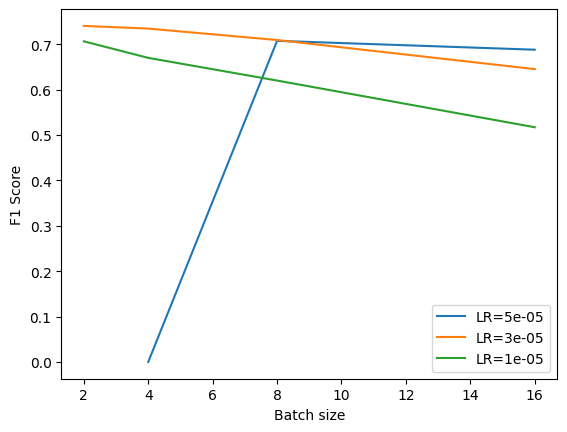

In [ ]:
# Extract unique learning rates from the DataFrame
learning_rates = hyperparam_results_subset20_bertlarge['learning_rate'].unique()

# Plot the results
for lr in learning_rates:
    temp_df = hyperparam_results_subset20_bertlarge[hyperparam_results_subset20_bertlarge['learning_rate'] == lr]

    # Sort temp_df by 'train_batch_size' before plotting
    temp_df = temp_df.sort_values(by='train_batch_size')

    plt.plot(temp_df['train_batch_size'], temp_df['f1_score'], label=f'LR={lr}')

plt.xlabel('Batch size')
plt.ylabel('F1 Score')
plt.legend()
plt.show()

##30%

In [ ]:
# Create a DataFrame to store the results
hyperparam_results_subset30_bertlarge = pd.DataFrame(columns=['learning_rate', 'train_batch_size', 'f1_score'])

In [ ]:
# Create a DataFrame to store the results
hyperparam_results_subset30_bertlarge = pd.read_csv('/content/gdrive/My Drive/MSc Project/hyperparam_results_subset30_bertlarge.csv')

In [ ]:
# Define the hyperparameters for tuning
HYPERPARAMETERS_TO_TUNE = {
    'learning_rate': [5e-5, 3e-5, 1e-5],
    'train_batch_size':[4, 8, 16],
}

# Select only the "original" dataset
dataset_key = "original_subset30"
dataset = all_datasets[dataset_key]

# Iterate over all combinations of hyperparameters
for lr in HYPERPARAMETERS_TO_TUNE['learning_rate']:
    for batch_size in HYPERPARAMETERS_TO_TUNE['train_batch_size']:
        # Call the function for each combination of hyperparameters
        result = train_and_evaluate_model(dataset, dataset_key, lr, batch_size)

        # Append results to the DataFrame
        hyperparam_results_subset30_bertlarge = hyperparam_results_subset30_bertlarge.append({
            'learning_rate': lr,
            'train_batch_size': batch_size,
            'f1_score': result['eval_f1'],
        }, ignore_index=True)
        # Save the DataFrame to the CSV file
        hyperparam_results_subset30_bertlarge.to_csv('/content/gdrive/My Drive/MSc Project/hyperparam_results_subset30_bertlarge.csv', index=False)

        # Remove the folder after processing
        folder_path = f"/content/bert-finetuned-{dataset_key}-lr-{lr}-batch-{batch_size}"
        !rm -r $folder_path


Training with original_subset30 data and lr 5e-05, batch_size 4...


Map:   0%|          | 0/2247 [00:00<?, ? examples/s]

Map:   0%|          | 0/3173 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-large-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,0.199100,0.154399,0.000000,0.500000,0.000000
2,0.155400,0.153604,0.000000,0.500000,0.000000
3,0.151900,0.153200,0.000000,0.500000,0.000000
4,0.152700,0.153123,0.000000,0.500000,0.000000
5,0.152900,0.153463,0.000000,0.500000,0.000000
6,0.152100,0.153365,0.000000,0.500000,0.000000
7,0.149400,0.154105,0.000000,0.500000,0.000000
8,0.150600,0.152927,0.000000,0.500000,0.000000
9,0.149600,0.153088,0.000000,0.500000,0.000000
10,0.151000,0.153047,0.000000,0.500000,0.000000


...

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-large-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,No log,0.184334,0.000000,0.500000,0.000000
2,No log,0.148493,0.124712,0.533375,0.014497


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,No log,0.184334,0.000000,0.500000,0.000000
2,No log,0.148493,0.124712,0.533375,0.014497
3,No log,0.131936,0.390939,0.631874,0.126694
4,0.199300,0.122141,0.528380,0.701761,0.259061
5,0.199300,0.111751,0.526989,0.692344,0.255594
6,0.199300,0.106596,0.571624,0.720957,0.295619
7,0.199300,0.103067,0.592701,0.732335,0.312953
8,0.104800,0.100524,0.601549,0.736077,0.315474
9,0.104800,0.099150,0.608531,0.740166,0.322408
10,0.104800,0.099034,0.608754,0.741361,0.322093


Results with original_subset30: {'eval_loss': 0.09903387725353241, 'eval_f1': 0.6087536103088204, 'eval_roc_auc': 0.7413613742231493, 'eval_accuracy': 0.3220926567916798, 'eval_runtime': 23.4026, 'eval_samples_per_second': 135.583, 'eval_steps_per_second': 8.503, 'epoch': 10.0}


<ipython-input-84-c78ce23f148f>:18: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  hyperparam_results_subset30_bertlarge = hyperparam_results_subset30_bertlarge.append({


In [ ]:
hyperparam_results_subset30_bertlarge

,learning_rate,train_batch_size,f1_score
0,0.00005,4.0,0.000000
1,0.00005,8.0,0.000000
2,0.00005,16.0,0.736852
3,0.00003,4.0,0.761728
4,0.00003,8.0,0.747177
5,0.00003,16.0,0.725593
6,0.00001,4.0,0.719166
7,0.00001,8.0,0.682212
8,0.00001,16.0,0.608754


In [ ]:
# Print out the best hyperparameters
best_hyperparams = hyperparam_results_subset30_bertlarge.loc[hyperparam_results_subset30_bertlarge['f1_score'].idxmax()]
print(f"Best hyperparameters for bert-large-uncased model:\n{best_hyperparams}")

Best hyperparameters for bert-large-uncased model:
learning_rate       0.000030
train_batch_size    4.000000
f1_score            0.761728
Name: 3, dtype: float64


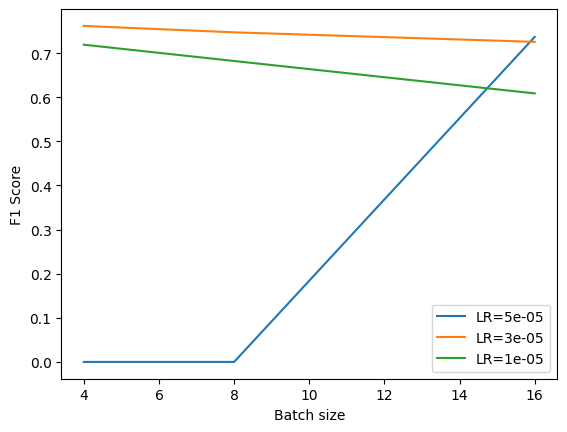

In [ ]:
# Extract unique learning rates from the DataFrame
learning_rates = hyperparam_results_subset30_bertlarge['learning_rate'].unique()

# Plot the results
for lr in learning_rates:
    temp_df = hyperparam_results_subset30_bertlarge[hyperparam_results_subset30_bertlarge['learning_rate'] == lr]

    # Sort temp_df by 'train_batch_size' before plotting
    temp_df = temp_df.sort_values(by='train_batch_size')

    plt.plot(temp_df['train_batch_size'], temp_df['f1_score'], label=f'LR={lr}')

plt.xlabel('Batch size')
plt.ylabel('F1 Score')
plt.legend()
plt.show()